# Create a figure showing the frame transformations and noise reductions in second order phase mod ccd


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet



In [2]:
steel_blue, plum = "#4682B4", "#B44682"

In [3]:
initial_state = np.array([1+0j, 0+0j])# |0> state
down_state= np.array([0+0j, 1+0j]) # |1> state
# initial_state = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) # |+> state

# Lab

In [14]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


tol = 10**-7
evaluation_points = 1000
evaluation_time = 4/rabi_freq 

times, states_lab = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_lab, 
                natural_freq = natural_freq,
                driving_freq = driving_freq,
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                phase_freq = phase_freq,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)


# times, states_lab_down = qt.evolve_state(down_state, evaluation_time, evaluation_points,  hamiltonians.ccd_lab, 
#                 natural_freq = natural_freq,
#                 driving_freq = driving_freq,
#                 rabi_freq = rabi_freq,
#                 phi_0 = phi_0,
#                 epsilon_m = epsilon_m,
#                 phase_freq = phase_freq,
#                 theta_m = theta_m,
#                 atol=tol,
#                 rtol=tol)




# First

In [5]:
times, states_first = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_rwa, 
                natural_freq = natural_freq,
                driving_freq = driving_freq,
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                phase_freq = phase_freq,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)

# Second

In [6]:
times, states_second = qt.evolve_state(initial_state, evaluation_time, evaluation_points,  hamiltonians.ccd_second_frame, 
                rabi_freq = rabi_freq,
                phi_0 = phi_0,
                epsilon_m = epsilon_m,
                theta_m = theta_m,
                atol=tol,
                rtol=tol)

# Combined

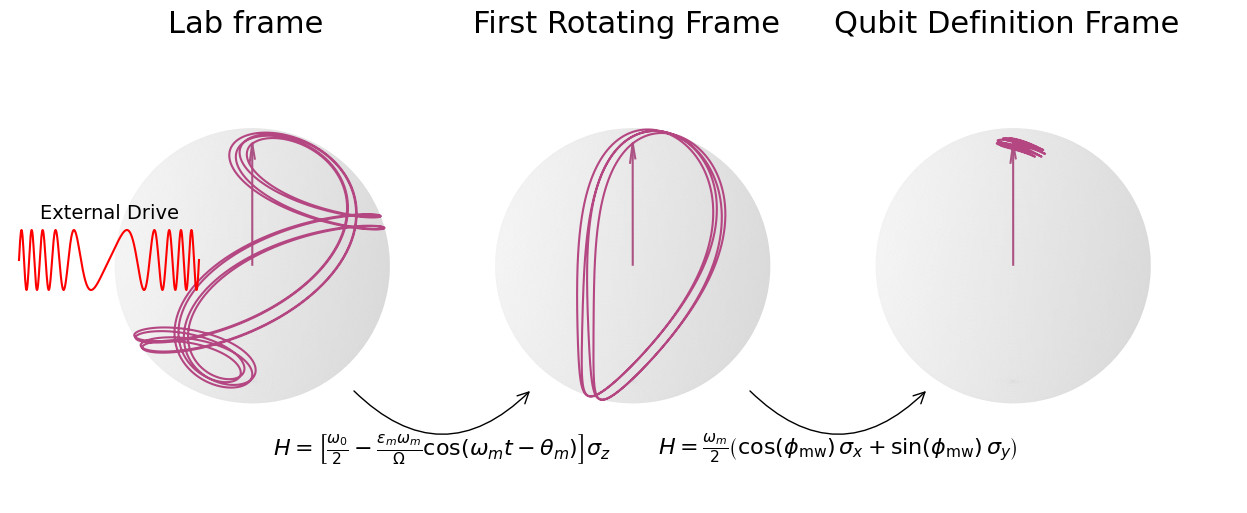

In [15]:
from matplotlib.patches import FancyArrowPatch

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(18, 6))

gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=-0.4)  # Very tight spacing

ax1 = fig.add_subplot(gs[0], projection='3d')
ax2 = fig.add_subplot(gs[1], projection='3d')
ax3 = fig.add_subplot(gs[2], projection='3d')


# Define the coordinates for the Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

# Draw Bloch sphere wireframe for each subplot
for ax in [ax1, ax2, ax3]:
    ax.plot_surface(x, y, z, rstride=1, cstride=1, color='lightgrey', alpha=0.1, linewidth=0)
    ax.grid(False)  # Disable background grid
    ax.set_axis_off()  # Remove axes
    ax.set_xlim([-1.0, 1.0])
    ax.set_ylim([-1.0, 1.0])
    ax.set_zlim([-1.0, 1.0])
    ax.set_box_aspect([1, 1, 1])  



# Recalculate the trajectories for the three states
x_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_x))
y_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_y))
z_expectation_lab = np.real(qt.calculate_expectations(states_lab, sigma_z))
# x_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_x))
# y_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_y))
# z_expectation_lab_down = np.real(qt.calculate_expectations(states_lab_down, sigma_z))

x_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_x))
y_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_y))
z_expectation_first = np.real(qt.calculate_expectations(states_first, sigma_z))

x_expectation_second = np.real(qt.calculate_expectations(states_second, sigma_x))
y_expectation_second = np.real(qt.calculate_expectations(states_second, sigma_y))
z_expectation_second = np.real(qt.calculate_expectations(states_second, sigma_z))

# Plot the trajectories on each Bloch sphere
ax1.plot(x_expectation_lab, y_expectation_lab, z_expectation_lab, color=plum, zorder=10)
ax1.quiver(0, 0, 0, x_expectation_lab[-1], y_expectation_lab[-1], z_expectation_lab[-1],
          arrow_length_ratio=0.15, color=plum, zorder=9)
# ax1.plot(x_expectation_lab_down, y_expectation_lab_down, z_expectation_lab_down, color=steel_blue, zorder=10)
# ax1.quiver(0, 0, 0, x_expectation_lab_down[-1], y_expectation_lab_down[-1], z_expectation_lab_down[-1],
#           arrow_length_ratio=0.15, color=steel_blue, zorder=9)

ax2.plot(x_expectation_first, y_expectation_first, z_expectation_first, color=plum, zorder=10)
ax2.quiver(0, 0, 0, x_expectation_first[-1], y_expectation_first[-1], z_expectation_first[-1],
          arrow_length_ratio=0.15, color=plum, zorder=9)

ax3.plot(x_expectation_second, y_expectation_second, z_expectation_second, color=plum, zorder=10)
ax3.quiver(0, 0, 0, x_expectation_second[-1], y_expectation_second[-1], z_expectation_second[-1],
          arrow_length_ratio=0.15, color=plum, zorder=9)

# add titles
ax1.set_title("Lab frame", fontsize=22)
ax2.set_title("First Rotating Frame", fontsize=22)
ax3.set_title("Qubit Definition Frame", fontsize=22)


# add inset showing phase modulation of cosine on the first qubit
# Add inset showing phase modulation of cosine on the first qubit
# Modify the inset to make it smaller, remove axes, and add an arrow pointing to the first qubit
ax1_inset = fig.add_axes([0.17, 0.46, 0.11, 0.11])  # Adjust inset position and size
t = np.linspace(0, 2 * np.pi, 500)  # Time array
mod = np.sin(driving_freq * t + 8 * np.sin(t))  # Phase modulation
ax1_inset.plot(t, mod, color='red')  # Plot the modulation
ax1_inset.set_axis_off()  # Remove axes
ax1_inset.set_title('External Drive', fontsize=14)  # Smaller title




# add curved arrows at the bottom pointing between the first and second qubit - and another between second and third qubit
from matplotlib.patches import FancyArrowPatch
import matplotlib.transforms as transforms

# Get the figure coordinate transform
transform = fig.transFigure
# Define the arrows in **figure coordinates** (0–1 range)
arrow1 = FancyArrowPatch((0.36, 0.3), (0.46, 0.3),  # between ax1 and ax2
                         transform=transform,
                         connectionstyle="arc3,rad=0.5",
                         arrowstyle="->", color="black", mutation_scale=20)

arrow2 = FancyArrowPatch((0.58, 0.3), (0.68, 0.3),  # between ax2 and ax3
                         transform=transform,
                         connectionstyle="arc3,rad=0.5",
                         arrowstyle="->", color="black", mutation_scale=20)

# Add to figure (not to axes!)
fig.patches.extend([arrow1, arrow2])

# Add labels below the arrows
# Midpoints of arcs (horizontal centre)
x1_mid = (0.36 + 0.46) / 2  # → 0.41
x2_mid = (0.58 + 0.68) / 2  # → 0.63

# Estimated bottom of arc (a bit below y = 0.3)
y_label = 0.2  # tweak as needed

# Add labels under the arcs
fig.text(x1_mid, y_label, 
         r"$H = \left[ \frac{\omega_0}{2} - \frac{\varepsilon_m \omega_m}{\Omega} \cos(\omega_m t - \theta_m) \right] \sigma_z$", 
         ha="center", va="center", fontsize=16)

fig.text(x2_mid, y_label, 
         r"$H= \frac{\omega_m}{2} \left( \cos(\phi_{\mathrm{mw}})\, \sigma_x + \sin(\phi_{\mathrm{mw}})\, \sigma_y \right)$", 
         ha="center", va="center", fontsize=16)


plt.savefig("/Users/archie/documents/year4/project/Figures/CCD_frame_transformations.png", dpi=600, bbox_inches='tight')
plt.show()
